# Tutorial02: Train 2D Classifier
> Created Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> Updated Aug. 2025: use mlinphysics module
> Harrison B. Prosper<br>


## Introduction

In this tutorial, we build a simple classifier, $f(\boldsymbol{x}, \boldsymbol{\omega})$, to classify the points in a 2D dataset sampled from a **mixture model** comprising two overlapping densities each modeled as a multivariate normal (that is, Gaussian) density,
\begin{align}
\mathcal{N}(x, \mu, \Sigma) & = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2} } \exp\left(-\frac{1}{2} z^T \Sigma^{-1} z \right),
\end{align}
where
\begin{align}
    x & = \begin{bmatrix}
            x_1 \\ x_2
            \end{bmatrix}, \quad
    \mu  = \begin{bmatrix}
            \mu_1 \\ \mu_2
            \end{bmatrix}, \quad
    z  = \begin{bmatrix}
            x_1 - \mu_1 \\ x_2 - \mu_2
            \end{bmatrix},\\
    \Sigma & = \begin{bmatrix}
        \Sigma_{11} & \Sigma_{12}\\
        \Sigma_{21} & \Sigma_{22}
    \end{bmatrix},
\end{align}
with the following mean and covariance matrices,
\begin{align}
    \color{blue}{\text{\bf Class } y = 1} &\nonumber\\
    \mu & = \begin{pmatrix} 0.25 &  -0.25\end{pmatrix},\\
    \Sigma & = \begin{pmatrix}
                    0.20 & 0.24 \\ 
                    0.24 & 0.40
                \end{pmatrix},\\
    \color{red}{\text{\bf Class } y = 0} &\nonumber\\
    \mu & = \begin{pmatrix}-0.10 &  0.10\end{pmatrix},\\
    \Sigma & = \begin{pmatrix}
                    0.60 & 0.40 \\ 
                    0.40 & 0.30
                \end{pmatrix} .
\end{align}

The best-fit values, $\widehat{\omega}$, of the classifier parameters are found by  minimizing the **empirical risk** $R(\omega)$ (aka **average loss**). The **binary cross entropy loss** (a special case of the **cross entropy loss** for claasification into more than two classes, and discussed in a later tutorial) is the standard loss for building a binary (that is, 2-class) classifier. 

The binary cross entropy loss is defined by 

$$L(y, f) = - [y \log f + (1 - y) \log(1-f)],$$ 

with the discrete targets $y \in \{0, 1\}$. In Lecture 2, it is shown that the best-fit function $f(\boldsymbol{x}, \widehat{\boldsymbol{\omega}})$ approximates the solution,  $f(\boldsymbol{x}, \boldsymbol{\omega}^*)$, to the equation
\begin{align*}
\int \, \frac{\partial L(y, f)}{\partial f} \, p(y | \boldsymbol{x}) \, dy & = 0,
\end{align*}
where $L(y, f)$ can be any (piece-wise) differentiable loss function.

From
\begin{align*}
0 & = \int \, \frac{\partial L(y, f)}{\partial f} \, p(y | \boldsymbol{x}) \, dy, \quad \text{ we see that}\\
    & = \int \,  \left( \frac{y}{f} - \frac{(1 - y)}{1-f}  \right) p(y | \boldsymbol{x}) \, dy,\\
    & = \frac{p(1 | \boldsymbol{x})}{f} - \frac{p(0 | \boldsymbol{x})}{1 -f},\\
   \frac{f}{1-f} & = \frac{p(1 | \boldsymbol{x})}{p(0 | \boldsymbol{x})},\quad \implies f  = p(1 | \boldsymbol{x}) ,
\end{align*}
we conclude that our classifier approximates the conditional probability $p(1 | \boldsymbol{x})$, that is, the probability that an object characterized by the **feature** vector $\boldsymbol{x}$ belongs to the class labeled by $y = 1$. This conclusion is independent of the details of the model $f(\boldsymbol{x}, \boldsymbol{\omega})$, but it does require 1) the latter to have sufficient **capacity**, that is, ability to approximate $f(\boldsymbol{x}, \boldsymbol{\omega}^*)$ and 2) that the minimizer can find a good approximation to the minimum of the risk functional, $R[f]$, by using its approximate proxy, $R(\omega)$. 

In [1]:
# standard system modules
import os, sys, re

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard statistical module
import scipy.stats as st

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt
#%matplotlib inline

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn

# ML in Physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon

# use for reloading modules that have been imported
import importlib

# update fonts
FONTSIZE = 12
plt.rcParams.update({
    "text.usetex": True, # turn OFF if the system can't find LaTex!
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "font.size": FONTSIZE
})

## Define exact density $p(x)$
Here we define the probability density of the data $p(x) = p(x|1) \pi(1) + p(x|0) \pi(0)$, where the class priors are $\pi(1) = \pi(0) = 0.5$.

Use the `%%writefile` magic command to write the cell contents to a file. The contents of file can then be imported into another notebook. 

In [3]:
%%writefile exactdensity.py
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
# -----------------------------------------------------------
class ExactDensity:
    
    def __init__(self):
        # Class y = 1
        self.rv1 = st.multivariate_normal(mean=[0.25, -0.25], 
                                          cov=[[0.20, 0.24], 
                                               [0.24, 0.40]])
        # Class y = 0
        self.rv2 = st.multivariate_normal(mean=[-0.10, 0.10], 
                                          cov=[[0.60, 0.40], 
                                               [0.40, 0.30]])

    def generate(self, filename=None, N=50_000):
        d1 = self.rv1.rvs(N)
        d2 = self.rv2.rvs(N)
        
        ones = np.ones(N)[:, np.newaxis]
        dd1  = np.hstack([d1, ones])  # stack horizontally

        zeros= np.zeros(N)[:, np.newaxis]
        dd2  = np.hstack([d2, zeros])
        
        dd = np.vstack([dd1, dd2])    # stack vertically
        np.random.shuffle(dd)

        df = pd.DataFrame(dd, columns=['x1', 'x2', 'y'])

        # save dataframe if requested
        if filename != None:
            df.to_csv(filename, index=False)
            
        return df
        
    def grid(self, flatten=False, xmin=-1, xmax=1, ymin=-1, ymax=1, N=100):
        xstep = (xmax-xmin)/N
        ystep = (ymax-ymin)/N
        x1, x2 = np.mgrid[xmin:xmax+xstep/2:xstep, ymin:ymax+ystep/2:ystep]
        if flatten:
            x1 = x1.flatten()
            x2 = x2.flatten()
        return x1, x2
        
    def __call__(self, x1, x2):
        # compute density at a grid of (x1, x2) points
        pos= np.dstack((x1, x2))
        p1 = self.rv1.pdf(pos)
        p0 = self.rv2.pdf(pos)
        return (p1 + p0)/2

    def prob(self, x1, x2):
        # compute p(y=1|x) at a grid of (x1, x2) points
        pos= np.dstack((x1, x2))
        p1 = self.rv1.pdf(pos)
        p0 = self.rv2.pdf(pos)
        return p1 / (p1 + p0)

    def plot(self, papprox=None, dataframe=None,
            xmin=-1, xmax=1, ymin=-1, ymax=1, fgsize=(5, 5)):
        x1, x2 = self.grid()
        
        fig = plt.figure(figsize=fgsize)
        ax  = fig.add_subplot(111)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        
        tickmarks = [-1.0, -0.5, 0.0, 0.5, 1.0]
        ax.set_xticks(tickmarks)
        ax.set_yticks(tickmarks)
        
        # plot p(x)
        plot_approx = type(papprox) != type(None)
        if not plot_approx:
            ax.contourf(x1, x2, self(x1, x2))

        if type(dataframe) != type(None):
            df = dataframe
            K = 1000
            xp, yp, _ = df[df.y > 0.5].to_numpy().T
            ax.scatter(xp[:K], yp[:K], s=0.8, color='cyan')

            xp, yp, _ = df[df.y < 0.5].to_numpy().T
            ax.scatter(xp[:K], yp[:K], s=0.8, color='red')

        # plot p(1|x)
        levels = np.arange(0.1, 1.0, 0.2) # values of p(1|x)
        pexact = self.prob(x1, x2)
        ax.contour(x1, x2, pexact, levels=levels, cmap='rainbow_r', linestyles='solid')

        if plot_approx:
            ax.contour(x1, x2, papprox, levels=levels, cmap='rainbow_r', linestyles='dashed')

        fig.tight_layout()
        plt.show()

Overwriting exactdensity.py


## Plot exact data density
  1. Plot $p(x)$
  2. Superimpose contours of constant $p(1|x)$

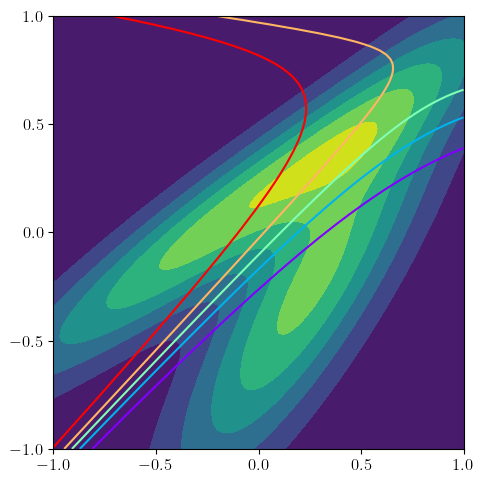

In [4]:
import exactdensity as dn
importlib.reload(dn)

fexact = dn.ExactDensity()
fexact.plot()

## Load data $x \sim p(x)$
Half of the points in the dataset are tagged with $y = 1$ (the $\color{blue}{\text{blue points}}$) and the other half are tagged with class label $y = 0$ (the red points).

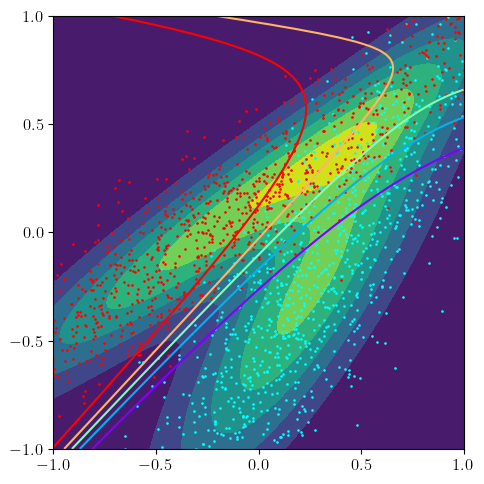

100000


,x1,x2,y
0,0.008251,-0.234339,1.0
1,1.056180,0.717379,1.0
2,0.709715,0.291953,1.0
3,-1.196716,-0.415832,0.0
4,-0.069331,0.184160,0.0
5,-0.861765,-0.261851,0.0
6,1.251563,1.024100,0.0
7,-1.104622,-0.722778,0.0
8,0.715288,0.772962,0.0
9,0.557766,0.548089,0.0


In [5]:
generate_data = False

data_file = '../data/two2dnormals.csv'

if generate_data:
    print('\n\tgenerate data\n')
    df = fexact.generate(filename=data_file)
else: 
    df = pd.read_csv(data_file)
    
fexact.plot(dataframe=df)

print(len(df))

df[:10]

## Training configuration

In [6]:
# computational device
# -----------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

# name of model
# -----------------------------------------
name = 'gauss2d'

# choose whether to create or load a configuration file
load_existing_config = False

if load_existing_config:
    # load configuration
    config = mlp.Config(f'{name}.yaml')
    
    # training configuration
    # -----------------------------------------
    train_size = config('train_size')         # training sample size
    test_size  = config('test_size')          # test sample size 
    val_size   = config('val_size')           # validation sample size 
    batch_size = config('batch_size')
    monitor_step = config('monitor_step')     # monitor training every n (=10) iterations
    
    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    n_steps = config('n_steps')               # number of training steps
    n_iters_per_step = config('n_iters_per_step')
    n_iterations = n_iters_per_step * n_steps # number of iterations
    
    base_lr = config('base_lr')               # initial learning rate
    gamma   = config('gamma')                 # learning rate scale factor
else:
    # create new configuration
    config = mlp.Config(name)
    
    # training configuration
    # -----------------------------------------
    train_size = config('train_size', 80_000)        # training sample size
    test_size  = config('test_size',  17_000)        # test sample size 
    val_size   = config('val_size',    3_000)        # validation sample size 
    batch_size = config('batch_size',    128)
    monitor_step = config('monitor_step', 10)        # monitor training every n (=10) iterations
    
    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    n_steps = config('n_steps', 1)                   # number of training steps
    n_iters_per_step = config('n_iters_per_step', 50_000)
    n_iterations = n_iters_per_step * n_steps        # number of iterations
    
    base_lr = config('base_lr', 1.e-4)               # initial learning rate
    gamma   = config('gamma', 0.5)                   # learning rate scale factor
    
    print(f'\nSave configuration to file {config.cfg_filename}\n')
    config.save()

print(config)

Available device: cpu 

Save configuration to file gauss2d_config.yaml

name: gauss2d
file:
  losses: gauss2d_losses.csv
  params: gauss2d_params.pth
  initparams: gauss2d_init_params.pth
train_size: 80000
test_size: 17000
val_size: 3000
batch_size: 128
monitor_step: 10
n_steps: 1
n_iters_per_step: 50000
base_lr: 0.0001
gamma: 0.5



## Create Datasets

Split data into inputs $\boldsymbol{x}$ and targets $y$.

In [7]:
# convert to numpy array
data = df.to_numpy()

# training dataset (this defines the empirical risk to be minimized)
train_data = dat.Dataset(data, 
                         start=0, 
                         end=train_size, 
                         split_data=2) # [0, 1], [2]

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
train_data_val = dat.Dataset(data, 
                             start=0, 
                             end=train_size,
                             random_sample_size=val_size,
                             split_data=2) # [0, 1], [2]

# validation dataset (for monitoring training)
val_data = dat.Dataset(data, 
                       start=train_size, 
                       end=train_size + val_size,
                       split_data=2)

# test dataset
test_data= dat.Dataset(data, 
                       start=train_size + val_size, 
                       end=train_size + val_size + test_size,
                       split_data=2)

Dataset
  shape of x: torch.Size([80000, 2])
  shape of y: torch.Size([80000, 1])

Dataset
  shape of x: torch.Size([3000, 2])
  shape of y: torch.Size([3000, 1])

Dataset
  shape of x: torch.Size([3000, 2])
  shape of y: torch.Size([3000, 1])

Dataset
  shape of x: torch.Size([17000, 2])
  shape of y: torch.Size([17000, 1])



## Save test data

In [8]:
import joblib
joblib.dump(test_data, '../data/test_data.pth')

['../data/test_data.pth']

## Create DataLoaders

In [9]:
train_loader = dat.DataLoader(train_data, 
                              batch_size=batch_size,
                              num_iterations=n_iterations)

train_loader_val = dat.DataLoader(train_data_val, 
                                  batch_size=len(train_data_val))

val_loader = dat.DataLoader(val_data, 
                            batch_size=len(val_data))

DataLoader
  Maximum number of iterations has been specified
  maxiter:           50000
  batch_size:          128
  shuffle_step:        625

DataLoader
  maxiter:               1
  batch_size:         3000
  shuffle_step:          1

DataLoader
  maxiter:               1
  batch_size:         3000
  shuffle_step:          1



## Define a fully-connected neural network

Use %%writefile to write the network structure to a file.

Note: $$\texttt{SiLU}(x) = \frac{x}{1 + \exp(-x)}$$

In [10]:
%%writefile gauss2d.py
import torch
import torch.nn as nn

class Gauss2D(nn.Module):
    
    def __init__(self, add_layernorm=False): 
        super().__init__()
        
        H = 15
        if add_layernorm:
            self.net = nn.Sequential(
                nn.Linear(2, H), nn.SiLU(), nn.LayerNorm(H),
                nn.Linear(H, H), nn.SiLU(), nn.LayerNorm(H),
                nn.Linear(H, H), nn.SiLU(), nn.LayerNorm(H),
                nn.Linear(H, 1), nn.Sigmoid())
        else:
            self.net = nn.Sequential(
                nn.Linear(2, H), nn.SiLU(), 
                nn.Linear(H, H), nn.SiLU(),
                nn.Linear(H, H), nn.SiLU(),
                nn.Linear(H, 1), nn.Sigmoid())

    def save(self, paramsfile):
        # save parameters of neural network
        torch.save(self.state_dict(), paramsfile)

    def load(self, paramsfile):
        # load parameters of neural network and set to eval mode
        self.load_state_dict(torch.load(paramsfile, 
                                        weights_only=True,
                                        map_location=torch.device('cpu')))
        self.eval()

    def forward(self, x):
        return self.net(x)

model = Gauss2D()

Overwriting gauss2d.py


## Instantiate training objects
  1. `model`
  2. `optimizer`
  3. `scheduler`
  4. `objective`

In [11]:
import gauss2d
importlib.reload(gauss2d)

model = gauss2d.model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=base_lr) 

scheduler = mlp.get_steplr_scheduler(optimizer, config)

# use Binary Cross Entropy loss 
objective = mlp.Objective(model, nn.BCELoss())

print(model)
print('number of parameters', mlp.number_of_parameters(model))

number of milestones:          0

Step | Milestone | LR
-----------------------------
   0 |         0 | 1.0e-04   
-----------------------------

number of iterations:          50000

Gauss2D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=15, bias=True)
    (1): SiLU()
    (2): Linear(in_features=15, out_features=15, bias=True)
    (3): SiLU()
    (4): Linear(in_features=15, out_features=15, bias=True)
    (5): SiLU()
    (6): Linear(in_features=15, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
number of parameters 541


## Train model

In [12]:
def train(objective, optimizer, scheduler, 
          train_loader, train_small_loader, val_loader,
          config):

    # get configuration info
    lossfile   = config('file/losses')
    paramsfile = config('file/params')
    step       = config('monitor_step', 10)
    delete     = config('delete', True)
    frac       = config('frac', 0.015)

    # instantiate object that saves average losses to 
    # a csv file for realtime monitoring

    number_iterations = len(train_loader)
    
    losswriter = mon.LossWriter(number_iterations, 
                                lossfile, 
                                step=step, 
                                delete=delete,
                                frac=frac, 
                                model=objective.model, 
                                paramsfile=paramsfile) 

    # instantiate learning rate step scheduler
    lrscheduler = mlp.LRStepScheduler(optimizer, scheduler)

    # -----------------------------
    # training loop
    # -----------------------------
    for ii, (x, y) in enumerate(train_loader):

        # set mode to training so that training-specific 
        # operations such as dropout, etc., are enabled.
        objective.train()

        # clear all gradients
        optimizer.zero_grad()

        # compute empirical risk
        R = objective(x, y)
        
        # compute gradients
        R.backward()

        # take one step downhill in the empirical risk landscape
        optimizer.step()

        # check whether to update learning rate
        lrscheduler.step()
        
        # I'm alive printout
        if (ii % step == 0) or (ii == number_iterations-1):
            
            t_loss = mlp.compute_avg_loss(objective, train_small_loader)
            
            v_loss = mlp.compute_avg_loss(objective, val_loader)

            # return current learning rate
            lr = lrscheduler.lr()

            # update loss file
            losswriter(ii, t_loss, v_loss, lr)


		learning rate:  1.000e-04
     49999|100.00%|00:00:22/00:00:00|2202.6 it/s|     50000|2.622e-01|2.672e-01|


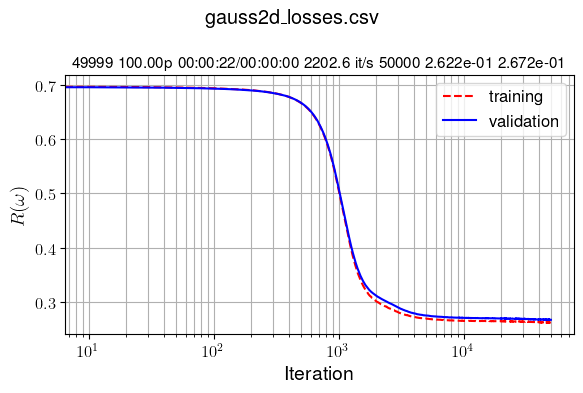

In [13]:
train(objective, optimizer, scheduler, 
      train_loader, train_loader_val, val_loader,
      config)

monitor = mon.Monitor(config('file/losses'))
monitor.plot(logx=True)